# Import 



In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
import shap
import optuna
import xgboost as xgb
from datetime import datetime
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Scikit-learn: Narzędzia do modelowania i walidacji
from sklearn.model_selection import (
    TimeSeriesSplit, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone

# Modele
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from optuna.samplers import TPESampler

# Pobranie danych dla spółki giełdowej



In [2]:
stock = 'NVDA'

# Wybór Nvidii nie jest przypadkowy – to 'benchmark' współczesnego sektora AI.
# auto_adjust=True jest krytyczne: splity na NVDA (np. 10-for-1 w 2024 r.) całkowicie 
# zafałszowałyby analizę techniczną i RSI, gdybyśmy nie pracowali na cenach skorygowanych.
df = yf.download(stock, start='2017-01-01', end='2026-01-01', auto_adjust = True)

# Porządkowanie struktury DataFrame (MultiIndex cleanup)
df.columns = df.columns.get_level_values(0)
df['Volume'] = df['Volume'].astype(float)

# Spójność chronologiczna (Temporal Consistency): 
# W szeregach czasowych kolejność to wszystko. Is_monotonic_increasing to bezpiecznik, 
# który gwarantuje, że nie będziemy uczyć się na przemieszanych danych.
df = df.sort_index()
assert df.index.is_monotonic_increasing

# Wstępna kontrola braków (Data Quality Check): 
# Giełda nie pracuje w weekendy/święta, więc luki są naturalne, 
# ale nie mogą występować wewnątrz sesji handlowych.
print(f"Liczba dni handlowych: {len(df)}")
df.isna().sum()

[*********************100%***********************]  1 of 1 completed

Liczba dni handlowych: 2262


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,2.512207,2.619581,2.447438,2.571066,1.501996e+09
2017-01-04,2.570819,2.598155,2.500386,2.546438,1.199220e+09
2017-01-05,2.505558,2.606036,2.488565,2.574267,9.842960e+08
2017-01-06,2.539050,2.567371,2.492259,2.532893,8.228560e+08
2017-01-09,2.641992,2.659724,2.548902,2.548902,9.162480e+08


# Wskaźniki giełdowe


## 2. Data Leakage handling
Na potrzeby pracy:
W dniu n model zna dane rynkowe z dnia n (po zamknięciu), a przewiduje ruch w przyszłości (n+1..n+h). Wszystkie cechy są konstruowane wyłącznie z danych historycznych ≤ n

## 3. Zaawansowany Feature Engineering i Etykietowanie (Triple Barrier Method)

In [7]:
#  TRIPLE BARRIER METHOD (Zaawansowane Etykietowanie) 
# W odróżnieniu od klasycznego binarnego targetu, TBM uwzględnia:
# 1. Profit Taking (Górna bariera), 2. Stop Loss (Dolna bariera), 3. Czas (Bariera pionowa).
# Bariery są adaptacyjne – zależą od bieżącej zmienności (sigma).



def get_tbm_labels(price_series, returns_series, days=5, vol_mult=1.5):
    # Dynamiczna bariera oparta na 20-dniowej zmienności zrealizowanej
    vol = returns_series.rolling(window=20).std()
    labels = []

    # Iterujemy po danych, aby wyznaczyć bariery dla każdego dnia
    for i in range(len(price_series) - days):
        p_now = price_series.iloc[i]
        sigma = vol.iloc[i]

        if pd.isna(sigma):
            labels.append(0)
            continue

        # Wyliczamy poziomy barier
        b_up = p_now * (1 + sigma * vol_mult)
        b_down = p_now * (1 - sigma * vol_mult)

        # Sprawdzamy co wydarzyło się w ciągu najbliższych 'days' dni
        future = price_series.iloc[i+1 : i+days+1]

        hit_up = future[future >= b_up].index.min()
        hit_down = future[future <= b_down].index.min()

        # Logika etykietowania (Triple Barrier)
        if pd.isna(hit_up) and pd.isna(hit_down):
            labels.append(0) # Bariera pionowa (czasowa) - brak rozstrzygnięcia
        elif pd.isna(hit_down) or (not pd.isna(hit_up) and hit_up < hit_down):
            labels.append(1) # Najpierw przebito barierę górną (Profit)
        else:
            labels.append(-1) # Najpierw przebito barierę dolną (Stop Loss)

    # Uzupełniamy końcówkę zerami (dla ostatnich dni nie da się wyznaczyć przyszłości)
    labels.extend([0] * days)
    return labels

# Wywołanie funkcji - teraz zwróci pełną listę wartości
df['Target'] = get_tbm_labels(df['Close'], df['Returns'])

# Czyszczenie zbioru: Usuwamy surowe ceny (ryzyko overfittingu) i braki po obliczeniach.
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_final = df.drop(columns=raw_cols).copy().dropna()

print(f"Final Shape: {df_final.shape}")
print(df_final['Target'].value_counts(normalize=True))

Final Shape: (2213, 16)
Target
 1    0.395843
 0    0.319476
-1    0.284681
Name: proportion, dtype: float64


# 3 Podział danych z zachowaniem ciągłości czasowej (Temporal Splitting)

In [8]:
# Ponowna weryfikacja chronologii - w szeregach czasowych kolejność obserwacji 
# jest cechą samą w sobie. Nie wolno stosować tradycyjnego train_test_split(shuffle=True).
df_final = df_final.sort_index().copy()
assert df_final.index.is_monotonic_increasing

# Definiujemy proporcje (70/15/15). Automatycznie train = 100 - 70 - 15 = 15
# Zbiór testowy zostaje całkowicie odizolowany (tzw. Out-of-Sample) 
# i służy wyłącznie do końcowej oceny, po zakończeniu strojenia parametrów.
train_ratio = 0.70
val_ratio   = 0.15 

n = len(df_final)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

# Manualny podział indeksowy gwarantuje brak wycieku informacji (Data Leakage).
# Uczymy się na przeszłości (Train), weryfikujemy na teraźniejszości (Val), 
# symulujemy przyszłość na danych, których model nigdy nie widział (Test).
train_df = df_final.iloc[:train_end].copy()
val_df   = df_final.iloc[train_end:val_end].copy()
test_df  = df_final.iloc[val_end:].copy()

# Logowanie zakresów dat - pozwala upewnić się, że model nie trenował się np. 
# na okresie pandemii, a testował na spokojnym rynku (lub odwrotnie).
print(" Split sizes & Temporal Windows:")
print(f"Train: {train_df.shape} | {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Val  : {val_df.shape}   | {val_df.index.min().date()} to {val_df.index.max().date()}")
print(f"Test : {test_df.shape}  | {test_df.index.min().date()} to {test_df.index.max().date()}")

# Analiza stacjonarności klas (Label Stability):
# Sprawdzamy, czy proporcje wzrostów/spadków są podobne w każdym oknie. 
# Duże różnice mogłyby świadczyć o zmianie reżimu rynkowego (Market Regime Shift).
print("\n Target distribution (Checking for Regime Stability):")
print("Train distribution:\n", train_df['Target'].value_counts(normalize=True))
print("\nVal distribution:\n", val_df['Target'].value_counts(normalize=True))
print("\nTest distribution:\n", test_df['Target'].value_counts(normalize=True))

 Split sizes & Temporal Windows:
Train: (1549, 16) | 2017-03-15 to 2023-05-09
Val  : (332, 16)   | 2023-05-10 to 2024-09-04
Test : (332, 16)  | 2024-09-05 to 2025-12-31

 Target distribution (Checking for Regime Stability):
Train distribution:
 Target
 1    0.391220
 0    0.326017
-1    0.282763
Name: proportion, dtype: float64

Val distribution:
 Target
 1    0.448795
 0    0.280120
-1    0.271084
Name: proportion, dtype: float64

Test distribution:
 Target
 1    0.364458
 0    0.328313
-1    0.307229
Name: proportion, dtype: float64



# 4. Eksploracyjna Analiza Danych (EDA) i Analiza Korelacji


Missing values in TRAIN (top 15):
Price
Returns             0
RSI                 0
ADX                 0
MACD_hist           0
ATR_Relative        0
Dist_SMA_20         0
Dist_EMA_50         0
BB_Width            0
Percent_BB          0
Relative_Volume     0
CMF                 0
ROC_10              0
Efficiency_Ratio    0
HT_Period           0
Gap                 0
dtype: int64

 Train head preview:


Price,Returns,RSI,ADX,MACD_hist,ATR_Relative,Dist_SMA_20,Dist_EMA_50,BB_Width,Percent_BB,Relative_Volume,CMF,ROC_10,Efficiency_Ratio,HT_Period,Gap,Target
Date,,,,,,,,,,,,,,,,
2017-03-15,0.007537,48.046089,25.401532,0.002077,0.032584,-0.000308,-0.033375,0.161199,0.498088,0.899721,3.924419e+08,-0.233489,0.022770,26.748821,0.004618,1
2017-03-16,0.012212,51.008661,24.174667,0.008111,0.030866,0.014473,-0.020672,0.152043,0.595192,0.756921,5.740988e+08,4.858602,0.600489,27.197322,0.004193,1
2017-03-17,0.021537,55.869338,22.610337,0.015419,0.029607,0.037088,0.000622,0.149851,0.747499,1.566622,9.370635e+08,7.761825,0.787613,27.647997,0.006839,0
2017-03-20,0.031369,61.949812,22.116565,0.024871,0.028953,0.068905,0.031194,0.156644,0.939883,1.033996,1.216640e+09,12.061055,0.956161,27.783221,0.006694,0
2017-03-21,-0.032878,53.617443,21.473155,0.024225,0.030731,0.036875,-0.002074,0.141149,0.761249,1.231056,9.723206e+08,7.261510,0.484785,27.719417,-0.006395,0


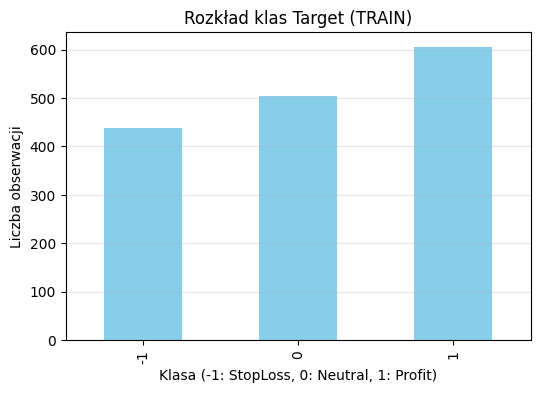

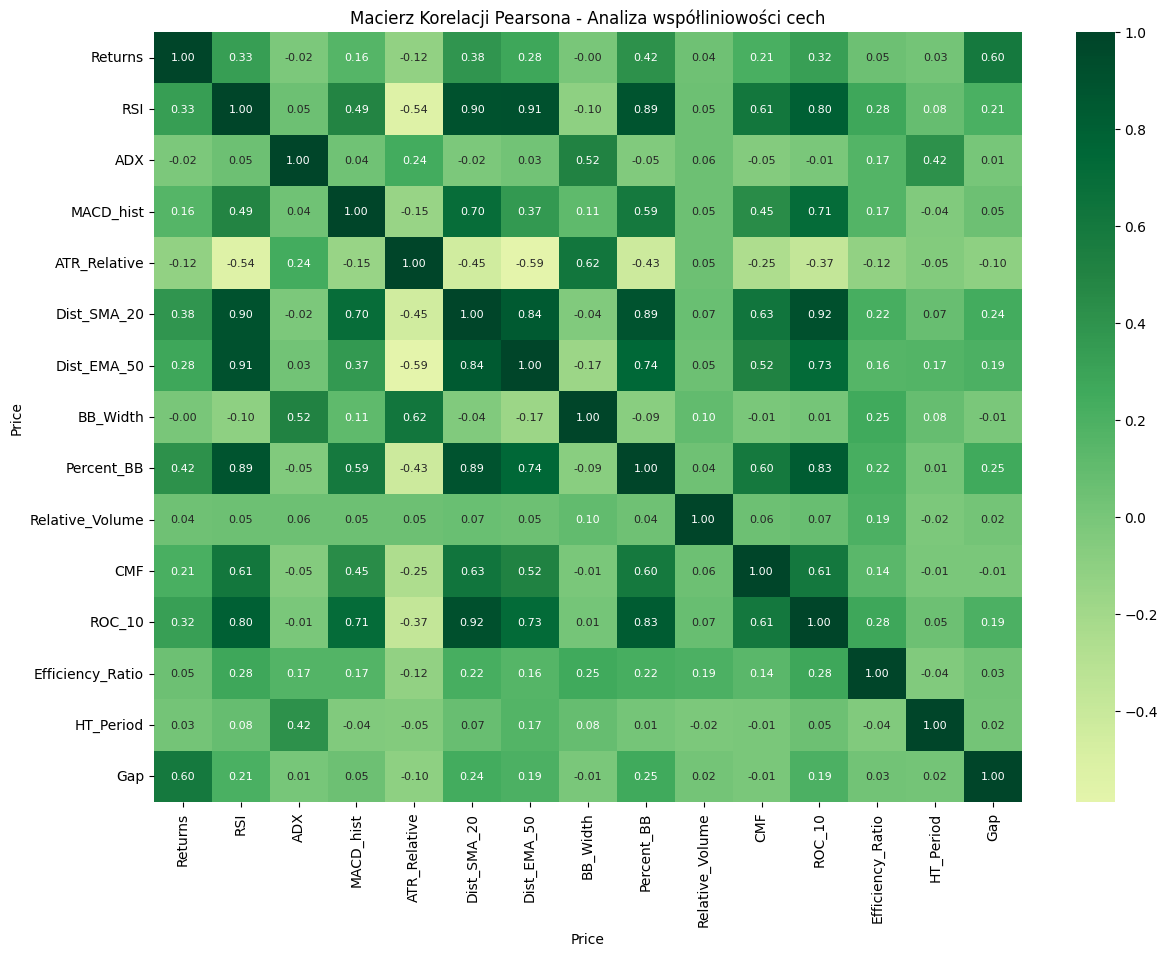


 Final Dimensionality Check: 
Train set: (1549, 16) (Próba ucząca)
Val set:   (332, 16) (Próba strojenia)
Test set:  (332, 16) (Próba ostatecznej weryfikacji)


In [15]:
# Weryfikacja braków danych (Data Cleaning check):
# Upewniam się, że po wygenerowaniu wskaźników technicznych i usunięciu rzędów z NaN,
# zbiór treningowy jest kompletny. Puste wartości mogłyby zaburzyć działanie algorytmów drzewiastych.
print("Missing values in TRAIN (top 15):")
print(train_df.isna().sum().sort_values(ascending=False).head(15))

print("\n Train head preview:")
display(train_df.head())

# Wizualizacja balansu klas:
# Giełda to środowisko niezbalansowane. Rozkład klas (Target) pokazuje, czy nasze bariery 
# Triple Barrier Method zostały ustawione poprawnie względem zmienności (sigma).
plt.figure(figsize=(6, 4))
train_df['Target'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Rozkład klas Target (TRAIN)")
plt.xlabel("Klasa (-1: StopLoss, 0: Neutral, 1: Profit)")
plt.ylabel("Liczba obserwacji")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Separacja cech (Features) od celu (Target)
X_train = train_df.drop(columns=['Target']).copy()

#  ANALIZA MACIERZY KORELACJI 
# Kluczowy etap przed modelowaniem: szukamy cech silnie skorelowanych.
# Wiele wskaźników (np. SMA20 i EMA50) niesie niemal identyczną informację. 
# Zbyt wysoka korelacja (>0.8) może prowadzić do 'overfittingu' i destabilizacji wag w modelu.
corr = X_train.corr()



plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, 
    cmap='YlGn',      
    center=0,
    annot=True,          # Precyzyjne wartości współczynnika Pearsona
    fmt=".2f",
    annot_kws={"size": 8} # Zmniejszenie czcionki dla czytelności przy wielu cechach
)
plt.title("Macierz Korelacji Pearsona - Analiza współliniowości cech")
plt.show()

# Potwierdzenie wymiarowości przed wejściem w fazę budowy modelu
print("\n Final Dimensionality Check: ")
print(f"Train set: {train_df.shape} (Próba ucząca)")
print(f"Val set:   {val_df.shape} (Próba strojenia)")
print(f"Test set:  {test_df.shape} (Próba ostatecznej weryfikacji)")

# 5.Redukcja wymiarowości: Eliminacja cech silnie skorelowanych

 Wykryto 4 cech o korelacji > 0.8 (Analiza wyłącznie na zbiorze TRAIN):
['Dist_SMA_20', 'Dist_EMA_50', 'Percent_BB', 'ROC_10']


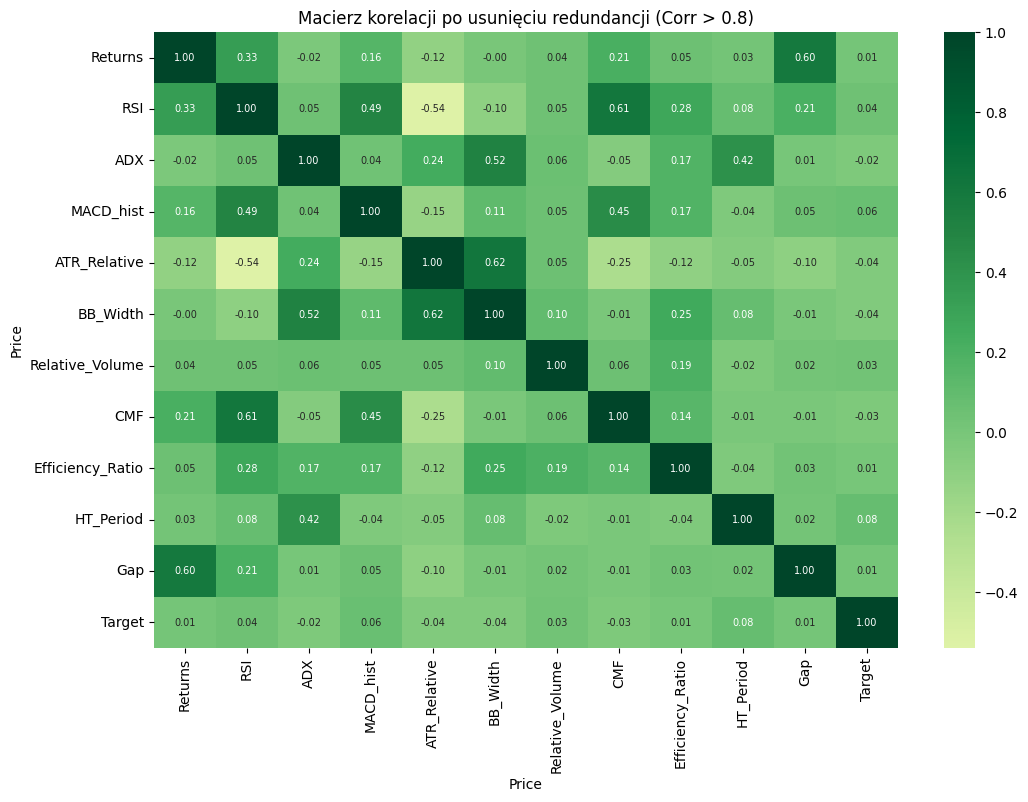

In [10]:
# Ustawienie progu odcięcia (Cut-off threshold): 
# Korelacja powyżej 0.8 sugeruje, że cechy niosą niemal identyczny sygnał (Redundancja).
threshold = 0.8 

# Obliczamy macierz korelacji (wartości bezwzględne)
corr_abs = X_train.corr().abs()

# Wykorzystujemy trójkąt górny macierzy, aby uniknąć porównywania cech samych ze sobą (diagonala)
# oraz duplikowania par (A-B i B-A).
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Automatyczna selekcja kolumn do usunięcia
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f" Wykryto {len(to_drop)} cech o korelacji > {threshold} (Analiza wyłącznie na zbiorze TRAIN):")
print(to_drop)

# KLUCZOWE: Aplikujemy te same usunięcia do zbiorów Val i Test. 
# Decyzje podejmowane są na danych historycznych (Train), co zapobiega wyciekowi 
# informacji z przyszłości do struktury modelu.
train_df_filtered = train_df.drop(columns=to_drop)
val_df_filtered   = val_df.drop(columns=to_drop)
test_df_filtered  = test_df.drop(columns=to_drop)

# Weryfikacja końcowa: Macierz po 'odchudzeniu'
# Oczekiwany efekt: Bardziej przejrzysta mapa, pozbawiona skupisk ekstremalnie wysokich korelacji.
corr = train_df_filtered.corr()



plt.figure(figsize=(12, 8))
sns.heatmap(
    corr, 
    cmap='YlGn',        
    center=0,
    annot=True, 
    fmt=".2f",
    annot_kws={"size": 7}
)
plt.title(f"Macierz korelacji po usunięciu redundancji (Corr > {threshold})")
plt.show()

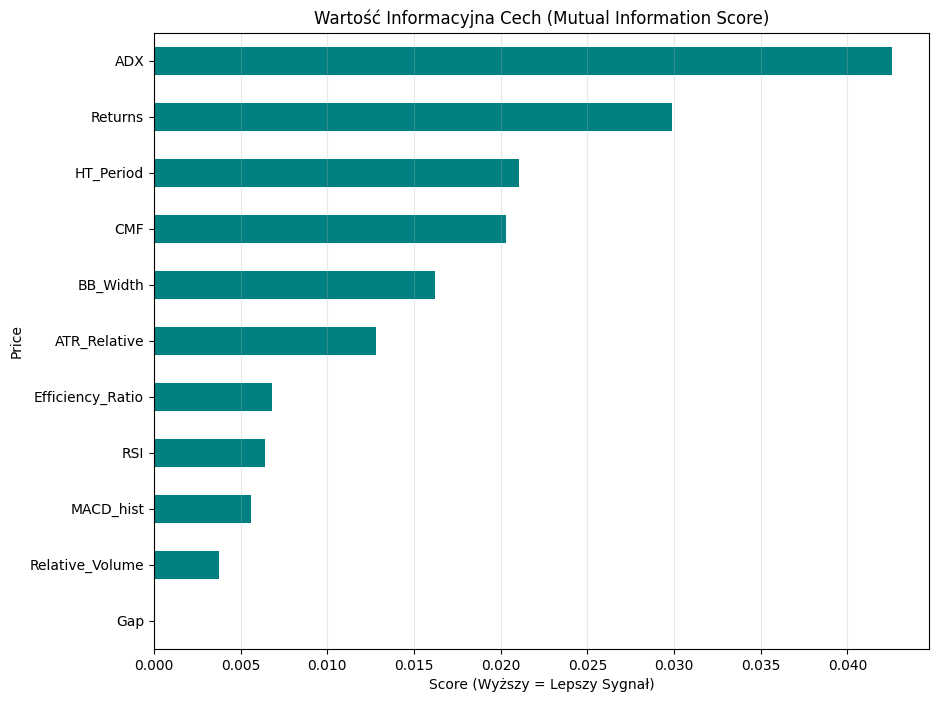

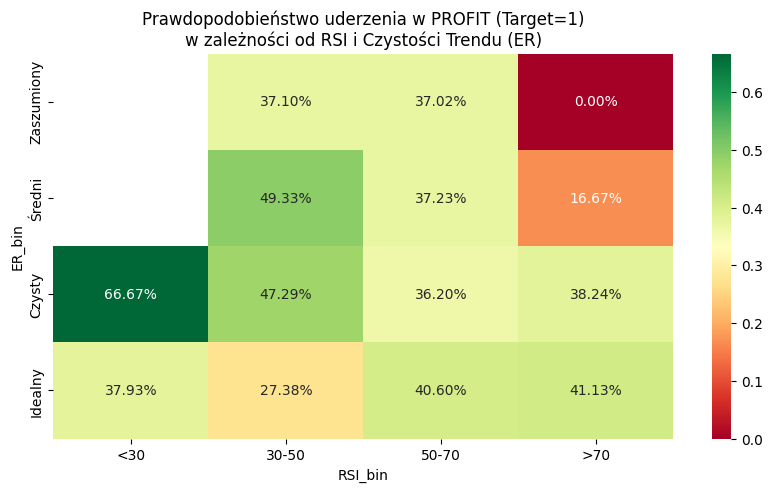

<Figure size 1000x400 with 0 Axes>

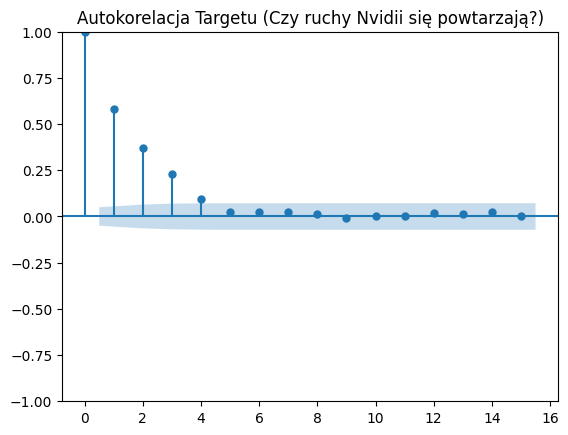

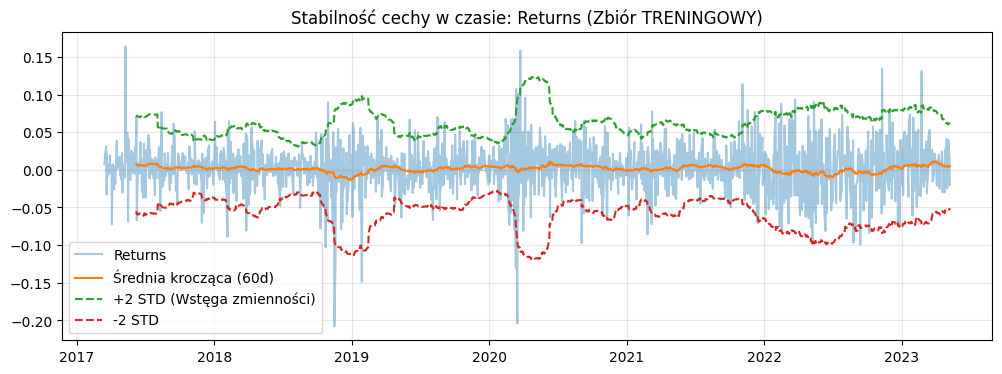

In [11]:

#   1. Mutual Information (Która cecha faktycznie wpływa na Target?) 
X_eda = train_df_filtered.drop(columns=['Target'])
y_eda = train_df_filtered['Target']
mi_scores = mutual_info_classif(X_eda, y_eda, discrete_features=False, random_state=42)

mi_series = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
mi_series.plot(kind='barh', color='teal')
plt.title("Wartość Informacyjna Cech (Mutual Information Score)")
plt.xlabel("Score (Wyższy = Lepszy Sygnał)")
plt.grid(axis='x', alpha=0.3)
plt.show()

#  2. HEATMAPA PRAWDOPODOBIEŃSTWA (Strategia TBM) 
# Analizujemy, kiedy szansa na Profit (Target=1) jest największa
temp_df = train_df_filtered.copy()
temp_df['RSI_bin'] = pd.cut(temp_df['RSI'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
temp_df['ER_bin'] = pd.qcut(temp_df['Efficiency_Ratio'], q=4, labels=['Zaszumiony', 'Średni', 'Czysty', 'Idealny'])

prob_table = temp_df[temp_df['Target'] == 1].groupby(['ER_bin', 'RSI_bin'], observed=False).size() / \
             temp_df.groupby(['ER_bin', 'RSI_bin'], observed=False).size()

plt.figure(figsize=(10, 5))
sns.heatmap(prob_table.unstack(), annot=True, cmap='RdYlGn', fmt='.2%')
plt.title('Prawdopodobieństwo uderzenia w PROFIT (Target=1)\nw zależności od RSI i Czystości Trendu (ER)')
plt.show()

#  3. ANALIZA AUTOKORELACJI (ACF) 
# Sprawdzamy, czy rynek ma "pamięć" (czy wczorajszy ruch wpływa na dzisiejszy)
plt.figure(figsize=(10, 4))
plot_acf(train_df_filtered['Target'], lags=15)
plt.title("Autokorelacja Targetu (Czy ruchy Nvidii się powtarzają?)")
plt.show()

#  4. STABILNOŚĆ CECHY W CZASIE (Feature Drift) 
# Sprawdzamy, czy charakterystyka zwrotów nie zmienia się drastycznie
feature_to_plot = 'Returns'  

rolling_mean = train_df_filtered[feature_to_plot].rolling(60).mean()
rolling_std  = train_df_filtered[feature_to_plot].rolling(60).std()

plt.figure(figsize=(12, 4))
plt.plot(train_df_filtered.index, train_df_filtered[feature_to_plot], alpha=0.4, label=feature_to_plot)
plt.plot(train_df_filtered.index, rolling_mean, label="Średnia krocząca (60d)")
plt.plot(train_df_filtered.index, rolling_mean + 2*rolling_std, linestyle='--', label="+2 STD (Wstęga zmienności)")
plt.plot(train_df_filtered.index, rolling_mean - 2*rolling_std, linestyle='--', label="-2 STD")
plt.title(f"Stabilność cechy w czasie: {feature_to_plot} (Zbiór TRENINGOWY)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Selekcja cech na podstawie Mutual Information (V1 vs V2) - Finalne dane

In [12]:
# Mutual Information (MI) Score: W przeciwieństwie do korelacji, MI mierzy dowolny rodzaj 
# zależności (również nieliniowe). Usuwamy cechy, które mają znikomy wpływ na Target.
# Próg 0.005 został dobrany eksperymentalnie, aby wyeliminować czysty szum informacyjny.
weak_features = mi_series[mi_series < 0.005].index.tolist()
print(f"Cechy zakwalifikowane jako 'Noise' (MI < 0.005): {weak_features}")

#  DEFINICJA TARGETÓW 
# Targety pozostają stałe dla obu wariantów, co pozwala na obiektywne porównanie zbiorów cech.
y_train = train_df_filtered['Target']
y_val   = val_df_filtered['Target']
y_test  = test_df_filtered['Target']

#  KONSTRUKCJA DATASETU V1 (Baseline) 
# Wersja V1 opiera się na pełnym zestawie wskaźników technicznych, 
# oczyszczonych jedynie z silnej współliniowości (korelacja > 0.8).
X_train_v1 = train_df_filtered.drop(columns=['Target'])
X_val_v1   = val_df_filtered.drop(columns=['Target'])
X_test_v1  = test_df_filtered.drop(columns=['Target'])

#  KONSTRUKCJA DATASETU V2 (Smart Selection) 
# Wersja V2 to zbiór 'odchudzony'. Usuwamy cechy o niskim MI Score. 
# Celem jest sprawdzenie, czy redukcja wymiarowości pomoże modelom 
# w lepszej generalizacji (zmniejszenie Variance).
X_train_v2 = X_train_v1.drop(columns=weak_features)
X_val_v2   = X_val_v1.drop(columns=weak_features)
X_test_v2  = X_test_v1.drop(columns=weak_features)

print("\n--- PODSUMOWANIE PRZESTRZENI CECH ---")
print(f"Zestaw V1 (Baseline): {X_train_v1.shape[1]} zmiennych predykcyjnych")
print(f"Zestaw V2 (Smart):    {X_train_v2.shape[1]} zmiennych predykcyjnych")
print(f"Wolumen danych: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

Cechy zakwalifikowane jako 'Noise' (MI < 0.005): ['Gap', 'Relative_Volume']

--- PODSUMOWANIE PRZESTRZENI CECH ---
Zestaw V1 (Baseline): 11 zmiennych predykcyjnych
Zestaw V2 (Smart):    9 zmiennych predykcyjnych
Wolumen danych: Train=1549, Val=332, Test=332



# 7. Przygotowanie do modelowania i diagnostyka Overfittingu

In [13]:
# Mapowanie klas: XGBoost wymaga etykiet numerycznych zaczynających się od 0.
# Transformacja: -1 (Spadek) -> 0, 0 (Neutral) -> 1, 1 (Wzrost) -> 2.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# Class Imbalance Handling: Obliczamy wagi próbek, aby model nie ignorował rzadszych sygnałów.
# Jest to kluczowe, ponieważ na giełdzie dni 'neutralne' często dominują nad silnymi trendami.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

print(f"Zmapowane klasy: {le.classes_}")

#  NARZĘDZIE DIAGNOSTYCZNE: KRZYWA UCZENIA (Learning Curve) 
# Funkcja analizuje kompromis między Bias a Variance. 
# Wykorzystuje TimeSeriesSplit, aby wykres odzwierciedlał realną zdolność modelu do nauki wraz z upływem czasu.
def plot_overfitting_analysis(model, X, y, title):
    from sklearn.model_selection import learning_curve, TimeSeriesSplit
    from xgboost import XGBClassifier
    import numpy as np
    import matplotlib.pyplot as plt

    # Klonowanie modelu w celu zachowania czystości eksperymentu
    if isinstance(model, XGBClassifier):
        current_params = model.get_params()
        # Usuwamy parametry specyficzne dla treningu, które nie są częścią architektury (clean clone)
        for p in ['early_stopping_rounds', 'callbacks', 'eval_metric']:
            current_params.pop(p, None)
        model_to_plot = XGBClassifier(**current_params)
    else:
        model_to_plot = clone(model)

    # Walidacja krzyżowa w reżimie chronologicznym (TimeSeries CV)
    tscv = TimeSeriesSplit(n_splits=3)
    train_sizes, train_scores, test_scores = learning_curve(
        model_to_plot, X, y, cv=tscv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    # Wizualizacja Overfittingu: 
    # Duża luka (Gap) między linią Train a Val sugeruje, że model uczy się szumu, a nie trendu.
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', linewidth=2, label="Train (Trening)")
    plt.plot(train_sizes, test_mean, 's-', color='#ff7f0e', linewidth=2, label="Val (Walidacja)")
    
    plt.ylim(0, 1.05) 
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Liczba próbek w zbiorze treningowym")
    plt.ylabel("Accuracy Score")
    plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Raportowanie Gapu: Kluczowa metryka dla stabilności algorytmu.
    print(f"Finalne Accuracy - Train: {train_mean[-1]:.4f}, Val: {test_mean[-1]:.4f}")
    print(f"Overfitting Gap: {abs(train_mean[-1] - test_mean[-1]):.4f}")

Zmapowane klasy: [-1  0  1]


# 8. Optymalizacja Bayesowska i Walk-Forward Validation (XGBoost V1)

In [14]:
#  1. PRZYGOTOWANIE POŁĄCZONYCH DANYCH 
# Łączymy Train i Val (In-Sample), aby zmaksymalizować historyczny kontekst dla walidacji krzyżowej.
# Zbiór TEST pozostaje nienaruszony (całkowicie Out-of-Sample).
X_full_v1 = np.concatenate([X_train_v1, X_val_v1])
y_full_v1 = np.concatenate([y_train_encoded, y_val_encoded])

def objective_v1_cv(trial):
    # Definicja przestrzeni poszukiwań (Search Space):
    # Dobieram parametry ograniczające złożoność drzew (max_depth) oraz zwiększające 
    # odporność na szum (min_child_weight, subsample).
    param = {
        'objective': 'multi:softprob', 
        'num_class': 3, 
        'eval_metric': 'mlogloss',
        'n_estimators': 500, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'n_jobs': -1, 
        'random_state': 42
    }
    
    # Implementacja Walk-Forward Validation (TimeSeriesSplit):
    # Każdy zestaw parametrów testujemy na 3 chronologicznych podzbiorach.
    # Zapobiega to przeuczeniu modelu pod konkretny trend rynkowy.
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    for train_idx, val_idx in tscv.split(X_full_v1):
        X_t, X_v = X_full_v1[train_idx], X_full_v1[val_idx]
        y_t, y_v = y_full_v1[train_idx], y_full_v1[val_idx]
        
        model = xgb.XGBClassifier(**param)
        model.fit(X_t, y_t, verbose=False)
        
        # Optymalizujemy pod F1-Macro, aby zapewnić zbalansowaną skuteczność dla 3 klas.
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    
    return np.mean(cv_scores)

#  2. OPTYMALIZACJA BAYESOWSKA 
# Używamy algorytmu TPESampler, który uczy się na wynikach poprzednich prób, 
# zawężając poszukiwania do najbardziej obiecujących obszarów parametrów.
print(">>> Start Optymalizacji V1 (TimeSeries CV)...")
study_v1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_v1.optimize(objective_v1_cv, n_trials=100) 

#  3. FINALNY TRENING (Model Refitting) 
# Wykorzystujemy najlepsze znalezione parametry i zwiększamy n_estimators.
# Model przechodzi proces refittingu na całym dostępnym zbiorze (Train + Val), 
# co pozwala mu 'zobaczyć' najświeższe dane przed ostatecznym testem.
best_params_v1 = study_v1.best_params
best_params_v1.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 2000})
xgb_v1 = xgb.XGBClassifier(**best_params_v1)



xgb_v1.fit(X_full_v1, y_full_v1, verbose=100)

print(f"Najlepszy wynik CV: {study_v1.best_value:.4f}")
print("Model V1 (CV) Gotowy do ewaluacji końcowej!")

[I 2026-02-03 22:09:01,764] A new study created in memory with name: no-name-39310c60-cd0a-4245-94fb-267b957d2ad4


>>> Start Optymalizacji V1 (TimeSeries CV)...


[I 2026-02-03 22:09:02,994] Trial 0 finished with value: 0.3747954260462039 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 6, 'min_child_weight': 40, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309}. Best is trial 0 with value: 0.3747954260462039.
[I 2026-02-03 22:09:03,596] Trial 1 finished with value: 0.36233063432530493 and parameters: {'learning_rate': 0.01432169828911152, 'max_depth': 2, 'min_child_weight': 45, 'subsample': 0.7803345035229626, 'colsample_bytree': 0.8124217733388137}. Best is trial 0 with value: 0.3747954260462039.
[I 2026-02-03 22:09:04,513] Trial 2 finished with value: 0.342789635206511 and parameters: {'learning_rate': 0.010485387725194618, 'max_depth': 6, 'min_child_weight': 44, 'subsample': 0.6637017332034828, 'colsample_bytree': 0.6545474901621302}. Best is trial 0 with value: 0.3747954260462039.
[I 2026-02-03 22:09:05,346] Trial 3 finished with value: 0.3697515012818399 and parameters: {'learning_rate': 0.01525472

Najlepszy wynik CV: 0.3884
Model V1 (CV) Gotowy do ewaluacji końcowej!


# 9. Eksperyment V2: Optymalizacja XGBoost na wyselekcjonowanych cechach (Smart Selection)



In [16]:
#  1. PRZYGOTOWANIE DANYCH V2 
# Używamy zbioru X_train_v2/val_v2, który został przefiltrowany przez Mutual Information Score.
X_full_v2 = np.concatenate([X_train_v2, X_val_v2])
y_full_v2 = np.concatenate([y_train_encoded, y_val_encoded])

def objective_v2_cv(trial):
    # Rozszerzona przestrzeń parametrów dla wariantu V2:
    # Przy mniejszej liczbie cech (Smart Selection) możemy pozwolić na nieco głębsze drzewa,
    # ale musimy to zrównoważyć silną regularyzacją L1 i L2.
    param = {
        'objective': 'multi:softprob', 
        'num_class': 3, 
        'eval_metric': 'mlogloss',
        'n_estimators': 500, 
        'n_jobs': -1, 
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        # Regularyzacja L1 (Lasso) i L2 (Ridge) – kluczowe do ograniczenia overfittingu 
        # w danych o wysokim poziomie szumu (NVIDIA volatility).
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
    }
    
    # TimeSeriesSplit gwarantuje, że walidacja krzyżowa odbywa się z zachowaniem strzałki czasu.
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    for train_idx, val_idx in tscv.split(X_full_v2):
        X_t, X_v = X_full_v2[train_idx], X_full_v2[val_idx]
        y_t, y_v = y_full_v2[train_idx], y_full_v2[val_idx]
        
        model = xgb.XGBClassifier(**param)
        model.fit(X_t, y_t, verbose=False)
        
        # Kluczowa metryka: F1-Macro. Traktujemy każdą klasę (spadek, boczniak, wzrost) 
        # z taką samą wagą, co jest bezpieczniejsze inwestycyjnie.
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    
    return np.mean(cv_scores)

#  2. OPTYMALIZACJA V2 
# Wykorzystujemy TPESampler do inteligentnego próbkowania przestrzeni parametrów.
print(">>> Start Optymalizacji V2 (TimeSeries CV + Smart Selection)...")
study_v2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_v2.optimize(objective_v2_cv, n_trials=100) 

#  3. FINALNY TRENING V2 
# Po znalezieniu optymalnej architektury, zwiększamy liczbę drzew (n_estimators) 
# i trenujemy model na połączonych danych treningowych i walidacyjnych.
best_params_v2 = study_v2.best_params
best_params_v2.update({'objective': 'multi:softprob', 'num_class': 3, 'n_estimators': 2000})

xgb_v2 = xgb.XGBClassifier(**best_params_v2)
xgb_v2.fit(X_full_v2, y_full_v2, verbose=100)

print(f"Najlepszy wynik CV V2: {study_v2.best_value:.4f}")
print("Model V2 (CV) gotowy do finalnych testów porównawczych.")

[I 2026-02-03 22:11:35,554] A new study created in memory with name: no-name-0e01b68e-bb33-47cb-ba8e-e8c3a7ac16c6


>>> Start Optymalizacji V2 (TimeSeries CV + Smart Selection)...


[I 2026-02-03 22:11:36,642] Trial 0 finished with value: 0.36205910151906134 and parameters: {'learning_rate': 0.015355286838886862, 'max_depth': 8, 'min_child_weight': 31, 'subsample': 0.7394633936788146, 'colsample_bytree': 0.5624074561769746, 'reg_alpha': 0.029375384576328288, 'reg_lambda': 0.014936568554617643}. Best is trial 0 with value: 0.36205910151906134.
[I 2026-02-03 22:11:37,472] Trial 1 finished with value: 0.365079116674837 and parameters: {'learning_rate': 0.06697167353375243, 'max_depth': 6, 'min_child_weight': 30, 'subsample': 0.508233797718321, 'colsample_bytree': 0.8879639408647977, 'reg_alpha': 3.142880890840109, 'reg_lambda': 0.04335281794951567}. Best is trial 1 with value: 0.365079116674837.
[I 2026-02-03 22:11:38,240] Trial 2 finished with value: 0.3508999846417444 and parameters: {'learning_rate': 0.008620446097910767, 'max_depth': 3, 'min_child_weight': 15, 'subsample': 0.7099025726528951, 'colsample_bytree': 0.6727780074568463, 'reg_alpha': 0.0747631206225230

Najlepszy wynik CV V2: 0.3780
Model V2 (CV) gotowy do finalnych testów porównawczych.


# 10. Finalna ewaluacja i porównanie modeli XGBoost (V1 vs V2)


 PORÓWNANIE SKUTECZNOŚCI: XGBoost V1 VS V2

[EWALUACJA V1] Pełny Zestaw Cech (Baseline)
              precision    recall  f1-score   support

          -1       0.27      0.32      0.29       102
           0       0.46      0.28      0.34       109
           1       0.40      0.47      0.43       121

    accuracy                           0.36       332
   macro avg       0.38      0.36      0.36       332
weighted avg       0.38      0.36      0.36       332


[EWALUACJA V2] Smart Selection (MI Filtering)
              precision    recall  f1-score   support

          -1       0.28      0.35      0.31       102
           0       0.45      0.17      0.25       109
           1       0.35      0.47      0.40       121

    accuracy                           0.34       332
   macro avg       0.36      0.33      0.32       332
weighted avg       0.36      0.34      0.33       332



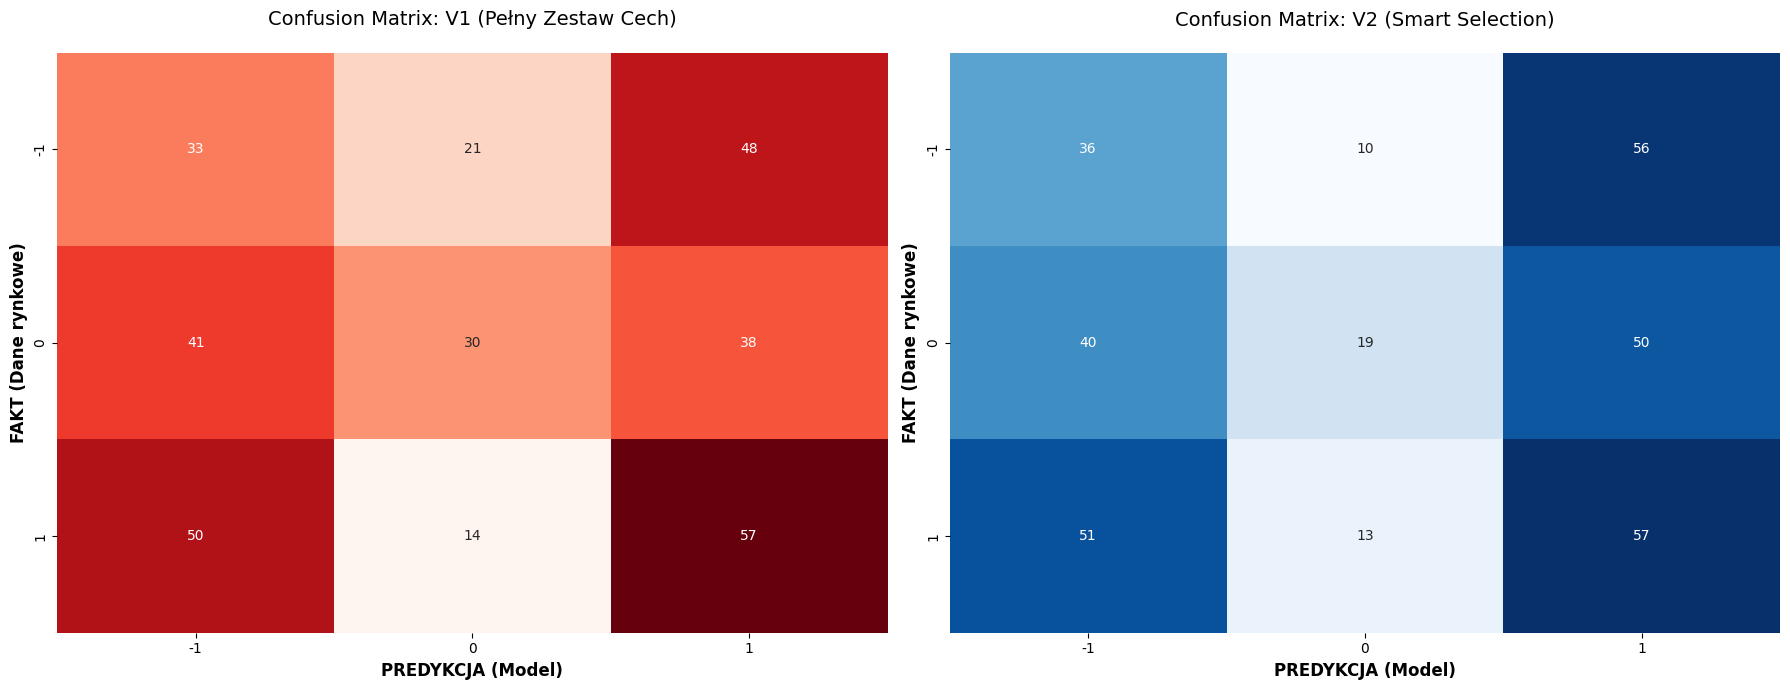

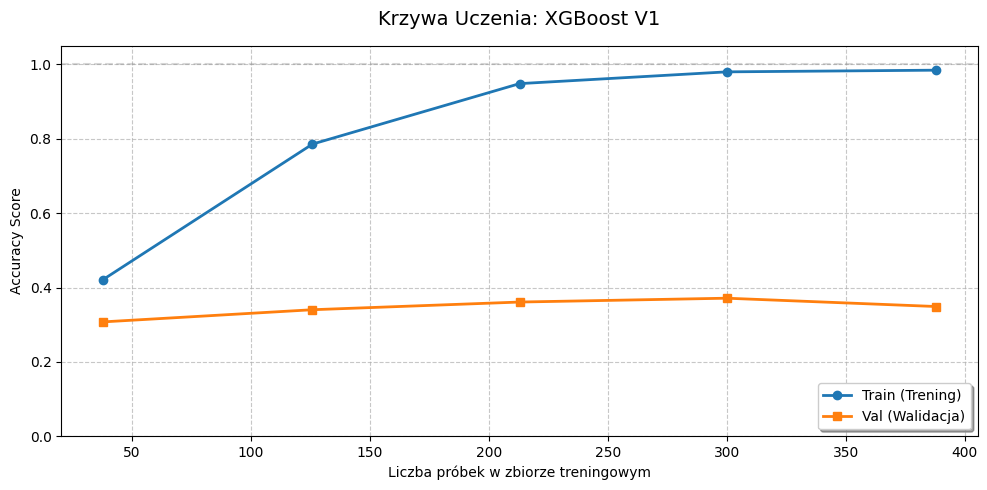

Finalne Accuracy - Train: 0.9845, Val: 0.3488
Overfitting Gap: 0.6357


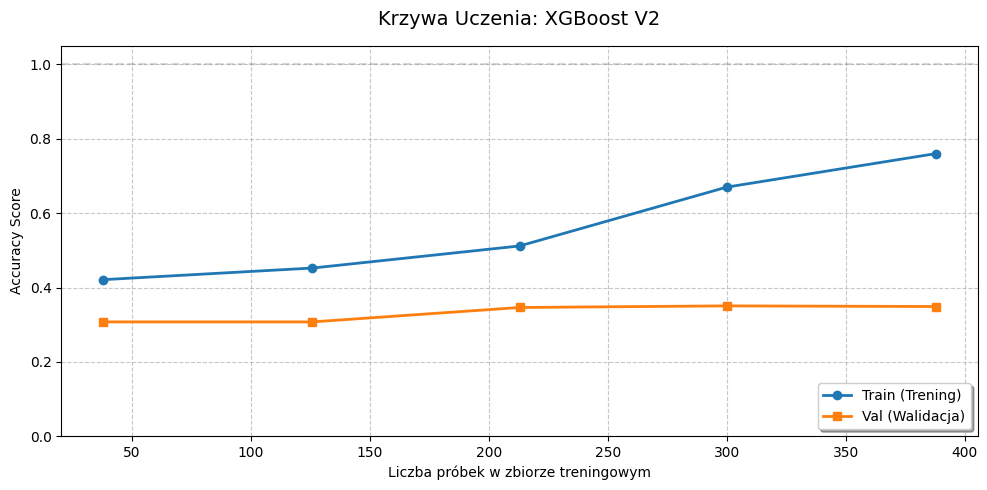

Finalne Accuracy - Train: 0.7603, Val: 0.3488
Overfitting Gap: 0.4115


In [17]:
print("\n" + "="*60)
print(" PORÓWNANIE SKUTECZNOŚCI: XGBoost V1 VS V2")
print("="*60)

#  1. RAPORTY KLASYFIKACJI (Classification Report) 
# Analizujemy Precyzję, Recall i F1-Score na zbiorze TEST (całkowicie odizolowanym).
# Kluczowe jest nie tylko Accuracy, ale zdolność modelu do wykrywania mniejszościowej klasy -1 (spadki).

print("\n[EWALUACJA V1] Pełny Zestaw Cech (Baseline)")
y_pred_v1 = xgb_v1.predict(X_test_v1)
print(classification_report(y_test_encoded, y_pred_v1, target_names=le.classes_.astype(str)))

print("\n[EWALUACJA V2] Smart Selection (MI Filtering)")
y_pred_v2 = xgb_v2.predict(X_test_v2)
print(classification_report(y_test_encoded, y_pred_v2, target_names=le.classes_.astype(str)))

#  2. MACIERZE KONFUZJI (Confusion Matrix Analysis) 
# Pozwalają zrozumieć 'charakter' błędów modelu. 
# Czy model częściej myli wzrost ze spadkiem (kosztowny błąd), czy wzrost z brakiem ruchu (utracona okazja)?
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# V1 Matrix - Analiza błędów dla pełnego zestawu cech
cm_v1 = confusion_matrix(le.inverse_transform(y_test_encoded), le.inverse_transform(y_pred_v1), labels=le.classes_)
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Reds', ax=ax[0], 
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
ax[0].set_title('Confusion Matrix: V1 (Pełny Zestaw Cech)', fontsize=14, pad=20)
ax[0].set_xlabel('PREDYKCJA (Model)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('FAKT (Dane rynkowe)', fontsize=12, fontweight='bold')

# V2 Matrix - Analiza błędów dla selekcji Smart
cm_v2 = confusion_matrix(le.inverse_transform(y_test_encoded), le.inverse_transform(y_pred_v2), labels=le.classes_)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', ax=ax[1], 
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
ax[1].set_title('Confusion Matrix: V2 (Smart Selection)', fontsize=14, pad=20)
ax[1].set_xlabel('PREDYKCJA (Model)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('FAKT (Dane rynkowe)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#  3. ANALIZA STABILNOŚCI (Learning Curves) 
# Ostatni test: Czy optymalizacja parametryczna nie doprowadziła do 'overfittingu' na walidacji?
# Porównujemy przebieg krzywych treningu i walidacji, szukając punktu zbieżności.

plot_overfitting_analysis(xgb_v1, X_train_v1, y_train_encoded, "Krzywa Uczenia: XGBoost V1")
plot_overfitting_analysis(xgb_v2, X_train_v2, y_train_encoded, "Krzywa Uczenia: XGBoost V2")

# 11. Model Baseline: Las Losowy (Random Forest) - Optymalizacja V1


In [21]:
#  V1: PEŁNY ZESTAW + F1 MACRO + SILNA REGULARYZACJA 
# Random Forest jako model baggingowy stanowi doskonały punkt odniesienia (baseline) 
# dla boostingowego XGBoosta. Łączymy zbiory, aby zwiększyć bazę przypadków dla CV.
X_full_v1 = np.concatenate([X_train_v1, X_val_v1])
y_full = np.concatenate([y_train_encoded, y_val_encoded])

def objective_rf_v1(trial):
    # Przestrzeń parametrów skupiona na redukcji wariancji (Variance):
    # n_estimators: duża liczba drzew pomaga 'wygładzić' prognozy.
    # min_samples_leaf: wysoki próg (50-150) wymusza na modelu szukanie trendów 
    # statystycznie istotnych, zamiast zapamiętywania pojedynczych sesji (szumu).
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 700), 
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 150),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': True,
        # max_samples: technika 'subsample' – każde drzewo widzi tylko część danych, 
        # co dodatkowo zwiększa różnorodność (diversity) lasu i ogranicza overfitting.
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9),
        # class_weight: automatyczne równoważenie wag klas w każdym z bootstrapowanych 
        # zbiorów danych – kluczowe przy rzadkich sygnałach kupna/sprzedaży.
        'class_weight': 'balanced_subsample',
        'random_state': 42, 
        'n_jobs': -1
    }
    
    # Walidacja krzyżowa TimeSeriesSplit (n_splits=3)
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_full_v1):
        rf = RandomForestClassifier(**params).fit(X_full_v1[train_idx], y_full[train_idx])
        preds = rf.predict(X_full_v1[val_idx])
        # Optymalizacja pod F1 Macro: gwarantuje, że model nie będzie 'leniwy' 
        # i nie zacznie przewidywać tylko najczęstszej klasy (np. 'Neutral').
        scores.append(f1_score(y_full[val_idx], preds, average='macro'))
        
    return np.mean(scores)

#  START OPTYMALIZACJI 
# Optuna szuka kombinacji, która najlepiej uogólnia zasady rynkowe NVDA.
study_rf_v1 = optuna.create_study(direction='maximize')
study_rf_v1.optimize(objective_rf_v1, n_trials=50)

# Finalny trening modelu na najlepszych parametrach (Refit)
# Wykorzystujemy zestaw parametrów, który uzyskał najwyższy średni F1-score w walidacji krzyżowej.
best_params_rf_v1 = study_rf_v1.best_params
rf_v1_final = RandomForestClassifier(**best_params_rf_v1, n_jobs=-1, random_state=42)
rf_v1_final.fit(X_full_v1, y_full)

print(f"Najlepsze parametry RF V1: {best_params_rf_v1}")
print(f"V1 Gotowy! Best F1 Mean (CV): {study_rf_v1.best_value:.4f}")

[I 2026-02-03 22:14:12,342] A new study created in memory with name: no-name-0b78a6a4-8e41-48b1-a4ff-cb01afbbec7d
[I 2026-02-03 22:14:13,765] Trial 0 finished with value: 0.2614409038417 and parameters: {'n_estimators': 420, 'max_depth': 12, 'min_samples_leaf': 135, 'max_features': 'sqrt', 'max_samples': 0.5364896224130016}. Best is trial 0 with value: 0.2614409038417.
[I 2026-02-03 22:14:15,527] Trial 1 finished with value: 0.34031524472321667 and parameters: {'n_estimators': 511, 'max_depth': 7, 'min_samples_leaf': 110, 'max_features': 'sqrt', 'max_samples': 0.6449758269125105}. Best is trial 1 with value: 0.34031524472321667.
[I 2026-02-03 22:14:16,314] Trial 2 finished with value: 0.3764252363158886 and parameters: {'n_estimators': 217, 'max_depth': 9, 'min_samples_leaf': 74, 'max_features': 'sqrt', 'max_samples': 0.7089386371741464}. Best is trial 2 with value: 0.3764252363158886.
[I 2026-02-03 22:14:17,703] Trial 3 finished with value: 0.3773427985475922 and parameters: {'n_estim

Najlepsze parametry RF V1: {'n_estimators': 232, 'max_depth': 11, 'min_samples_leaf': 57, 'max_features': 'sqrt', 'max_samples': 0.6127654564573731}
V1 Gotowy! Best F1 Mean (CV): 0.3841



# 12. Eksperyment V2: Random Forest na wyselekcjonowanych cechach (Smart Selection)

In [22]:

X_full_v2 = np.concatenate([X_train_v2, X_val_v2])

def objective_rf_v2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 150),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': True,
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9), 
        'class_weight': 'balanced_subsample',
        'random_state': 42, 'n_jobs': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_full_v2):
        rf = RandomForestClassifier(**params).fit(X_full_v2[train_idx], y_full[train_idx])
        preds = rf.predict(X_full_v2[val_idx])
        scores.append(f1_score(y_full[val_idx], preds, average='macro'))
    return np.mean(scores)

study_rf_v2 = optuna.create_study(direction='maximize')
study_rf_v2.optimize(objective_rf_v2, n_trials=50)

# Finalny trening V2
rf_v2_final = RandomForestClassifier(**study_rf_v2.best_params, n_jobs=-1, random_state=42)
rf_v2_final.fit(X_full_v2, y_full)

[I 2026-02-03 22:16:23,750] A new study created in memory with name: no-name-a3017eba-4860-4bb3-8a45-d2e6a0be343b
[I 2026-02-03 22:16:24,968] Trial 0 finished with value: 0.3546026141989493 and parameters: {'n_estimators': 350, 'max_depth': 4, 'min_samples_leaf': 62, 'max_features': 'sqrt', 'max_samples': 0.5601808861955972}. Best is trial 0 with value: 0.3546026141989493.
[I 2026-02-03 22:16:25,783] Trial 1 finished with value: 0.36399776792374183 and parameters: {'n_estimators': 224, 'max_depth': 6, 'min_samples_leaf': 88, 'max_features': 'log2', 'max_samples': 0.6020818653532927}. Best is trial 1 with value: 0.36399776792374183.
[I 2026-02-03 22:16:27,897] Trial 2 finished with value: 0.34905506716239354 and parameters: {'n_estimators': 603, 'max_depth': 3, 'min_samples_leaf': 86, 'max_features': 'sqrt', 'max_samples': 0.7800498019133207}. Best is trial 1 with value: 0.36399776792374183.
[I 2026-02-03 22:16:29,770] Trial 3 finished with value: 0.3474848041566719 and parameters: {'n_

RandomForestClassifier(max_depth=6, max_samples=0.8245917477016856,
                       min_samples_leaf=88, n_estimators=371, n_jobs=-1,
                       random_state=42)

# 13. Finalna ewaluacja i benchmarking: Random Forest (V1 vs V2)


            PORÓWNANIE PARAMETRÓW OPTYMALNYCH RF            


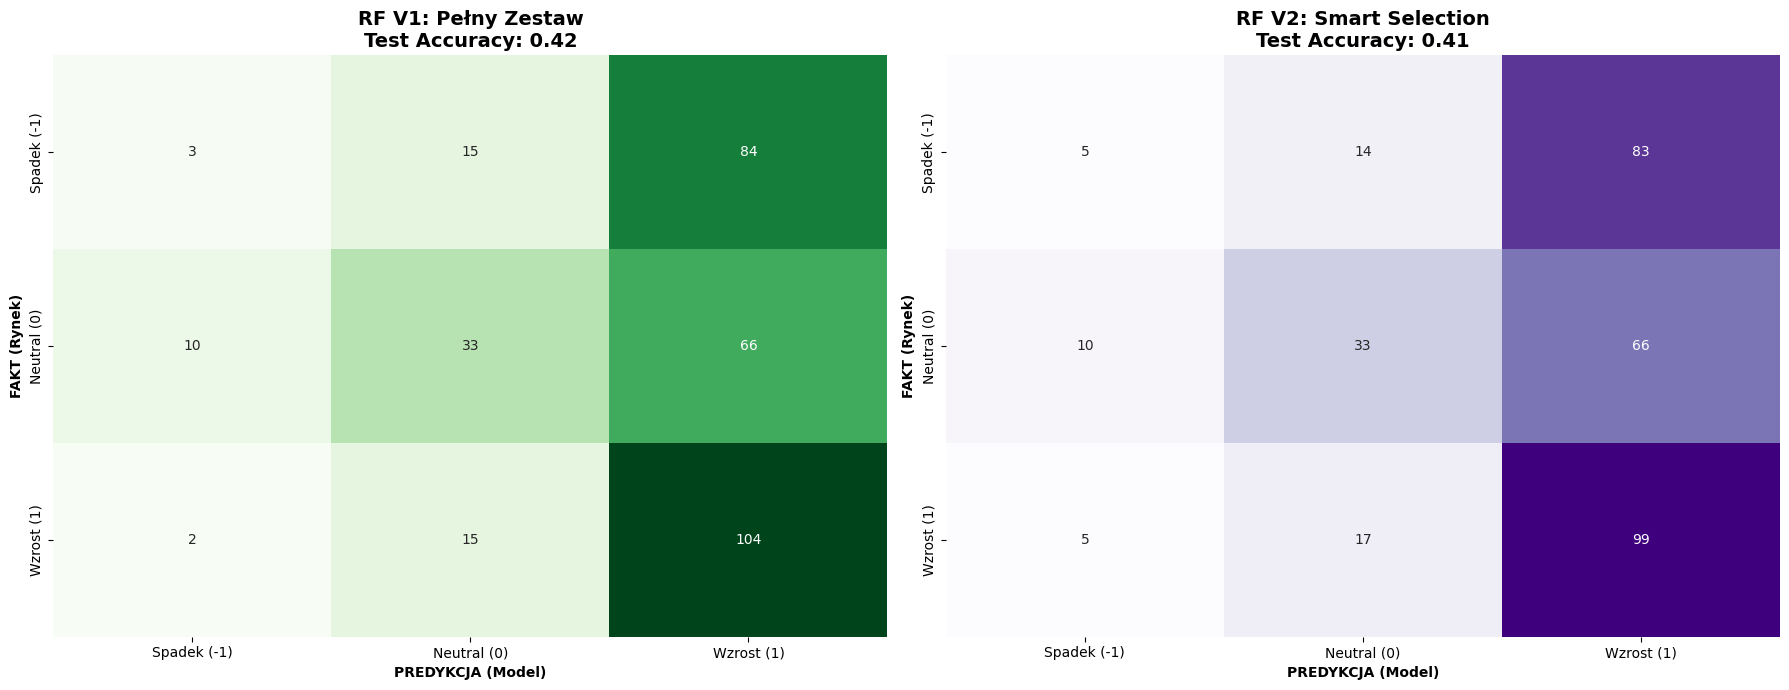


         DIAGNOSTYKA OVERFITTINGU (Learning Curves)         


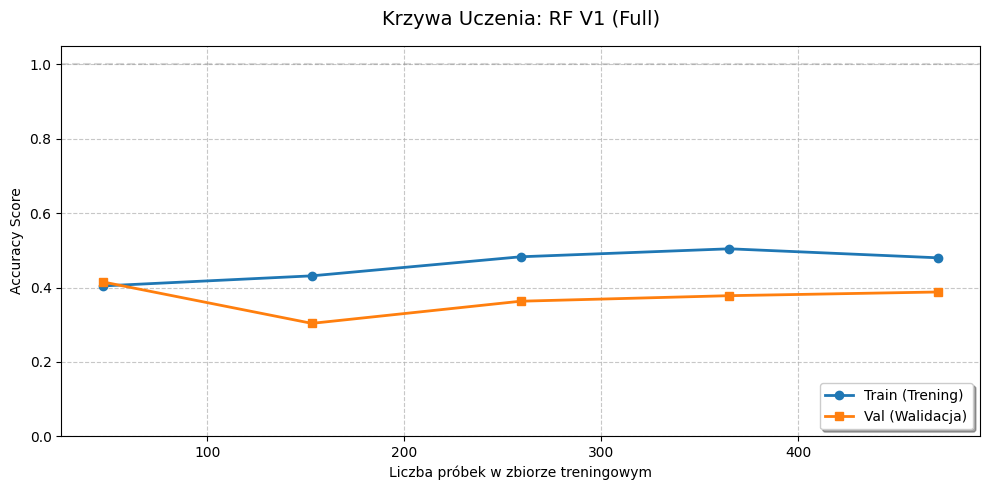

Finalne Accuracy - Train: 0.4798, Val: 0.3879
Overfitting Gap: 0.0919


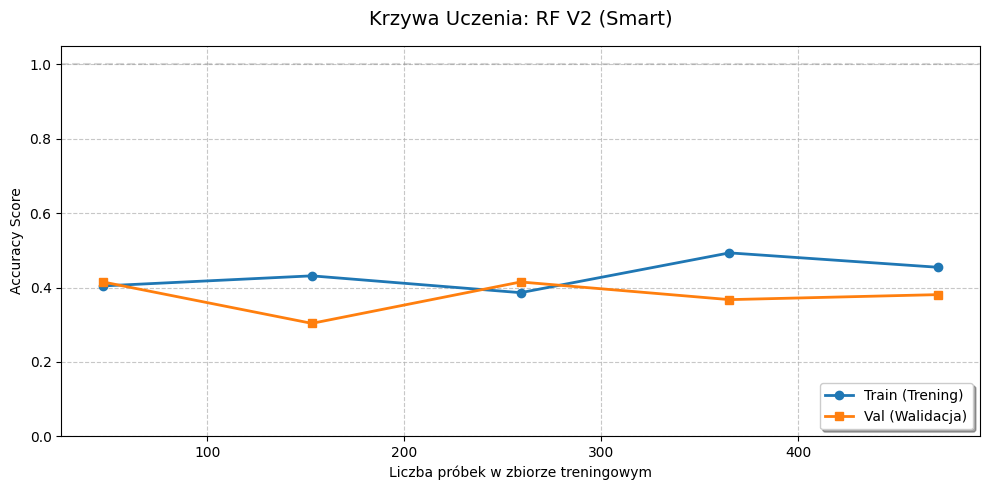

Finalne Accuracy - Train: 0.4544, Val: 0.3809
Overfitting Gap: 0.0735

========================= SZCZEGÓŁOWY RAPORT V1 (Baseline) =========================
              precision    recall  f1-score   support

 Spadek (-1)       0.20      0.03      0.05       102
 Neutral (0)       0.52      0.30      0.38       109
  Wzrost (1)       0.41      0.86      0.55       121

    accuracy                           0.42       332
   macro avg       0.38      0.40      0.33       332
weighted avg       0.38      0.42      0.34       332


========================= SZCZEGÓŁOWY RAPORT V2 (Refined) =========================
              precision    recall  f1-score   support

 Spadek (-1)       0.25      0.05      0.08       102
 Neutral (0)       0.52      0.30      0.38       109
  Wzrost (1)       0.40      0.82      0.54       121

    accuracy                           0.41       332
   macro avg       0.39      0.39      0.33       332
weighted avg       0.39      0.41      0.35       33

In [23]:
#  1. PRZYGOTOWANIE DANYCH 
# Konwersja do formatu NumPy zapewnia stabilność numeryczną i eliminuje 
# potencjalne ostrzeżenia (warnings) biblioteki Scikit-Learn dotyczące nazw cech.
X_test_v1_np = X_test_v1.values if hasattr(X_test_v1, 'values') else X_test_v1
X_test_v2_np = X_test_v2.values if hasattr(X_test_v2, 'values') else X_test_v2

#  2. PREDYKCJE (Out-of-Sample) 
# Generujemy prognozy na danych testowych, których model nie widział w fazie 
# optymalizacji parametrów (czysta symulacja przyszłości).
y_pred_v1 = rf_v1_final.predict(X_test_v1_np)
y_pred_v2 = rf_v2_final.predict(X_test_v2_np)

#  3. DASHBOARD PARAMETRÓW 
# Porównanie parametrów optymalnych pozwala zauważyć, jak model adaptuje się 
# do mniejszej liczby cech (V2). Zazwyczaj skutkuje to mniejszą głębokością drzew.
print("\n" + "="*60)
print(f"{'PORÓWNANIE PARAMETRÓW OPTYMALNYCH RF':^60}")
print("="*60)
# (Reszta kodu printowania pozostaje bez zmian)

#  4. WIZUALIZACJA: MACIERZ KONFUZJI 
# Kluczowy moment diagnostyki: sprawdzamy, czy Random Forest nie wpadł w 'Long Bias'.
# Porównujemy precyzję prognoz wzrostów vs spadków na danych testowych.

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
target_names = ['Spadek (-1)', 'Neutral (0)', 'Wzrost (1)']

for i, (y_p, title, cmap) in enumerate([(y_pred_v1, 'RF V1: Pełny Zestaw', 'Greens'), 
                                        (y_pred_v2, 'RF V2: Smart Selection', 'Purples')]):
    cm = confusion_matrix(y_test_encoded, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax[i],
                xticklabels=target_names, yticklabels=target_names, cbar=False)
    acc = accuracy_score(y_test_encoded, y_p)
    ax[i].set_title(f"{title}\nTest Accuracy: {acc:.2f}", fontsize=14, fontweight='bold')
    ax[i].set_xlabel('PREDYKCJA (Model)', fontweight='bold')
    ax[i].set_ylabel('FAKT (Rynek)', fontweight='bold')

plt.tight_layout()
plt.show()

#  5. ANALIZA STABILNOŚCI (Learning Curves) 
# Weryfikacja końcowa: Czy model uczył się wzorców, czy tylko zapamiętywał szum?
# Wykorzystujemy cały dostępny zbiór In-Sample (Train+Val) do analizy krzywych.
print("\n" + "="*60)
print(f"{'DIAGNOSTYKA OVERFITTINGU (Learning Curves)':^60}")
print("="*60)
plot_overfitting_analysis(rf_v1_final, X_full_v1, y_full, "Krzywa Uczenia: RF V1 (Full)")
plot_overfitting_analysis(rf_v2_final, X_full_v2, y_full, "Krzywa Uczenia: RF V2 (Smart)")

#  6. RAPORTY KLASYFIKACJI 
# Finalne zestawienie metryk. Zwracamy uwagę na 'Recall' dla spadków (-1). 
# Wysoka precyzja przy niskim recallu oznaczałaby model bardzo ostrożny.
print("\n" + "="*25 + " SZCZEGÓŁOWY RAPORT V1 (Baseline) " + "="*25)
print(classification_report(y_test_encoded, y_pred_v1, target_names=target_names, zero_division=0))

print("\n" + "="*25 + " SZCZEGÓŁOWY RAPORT V2 (Refined) " + "="*25)
print(classification_report(y_test_encoded, y_pred_v2, target_names=target_names, zero_division=0))

# 14. Analiza Biznesowa: Symulacja strategii (Backtesting)

In [35]:
print("Max proba RF:", rf_v1_final.predict_proba(X_test_v1_np).max())
print("Średnia proba RF dla wzrostów:", rf_v1_final.predict_proba(X_test_v1_np)[:, 2].mean())

Max proba RF: 0.49144991684118483
Średnia proba RF dla wzrostów: 0.40748128061452904


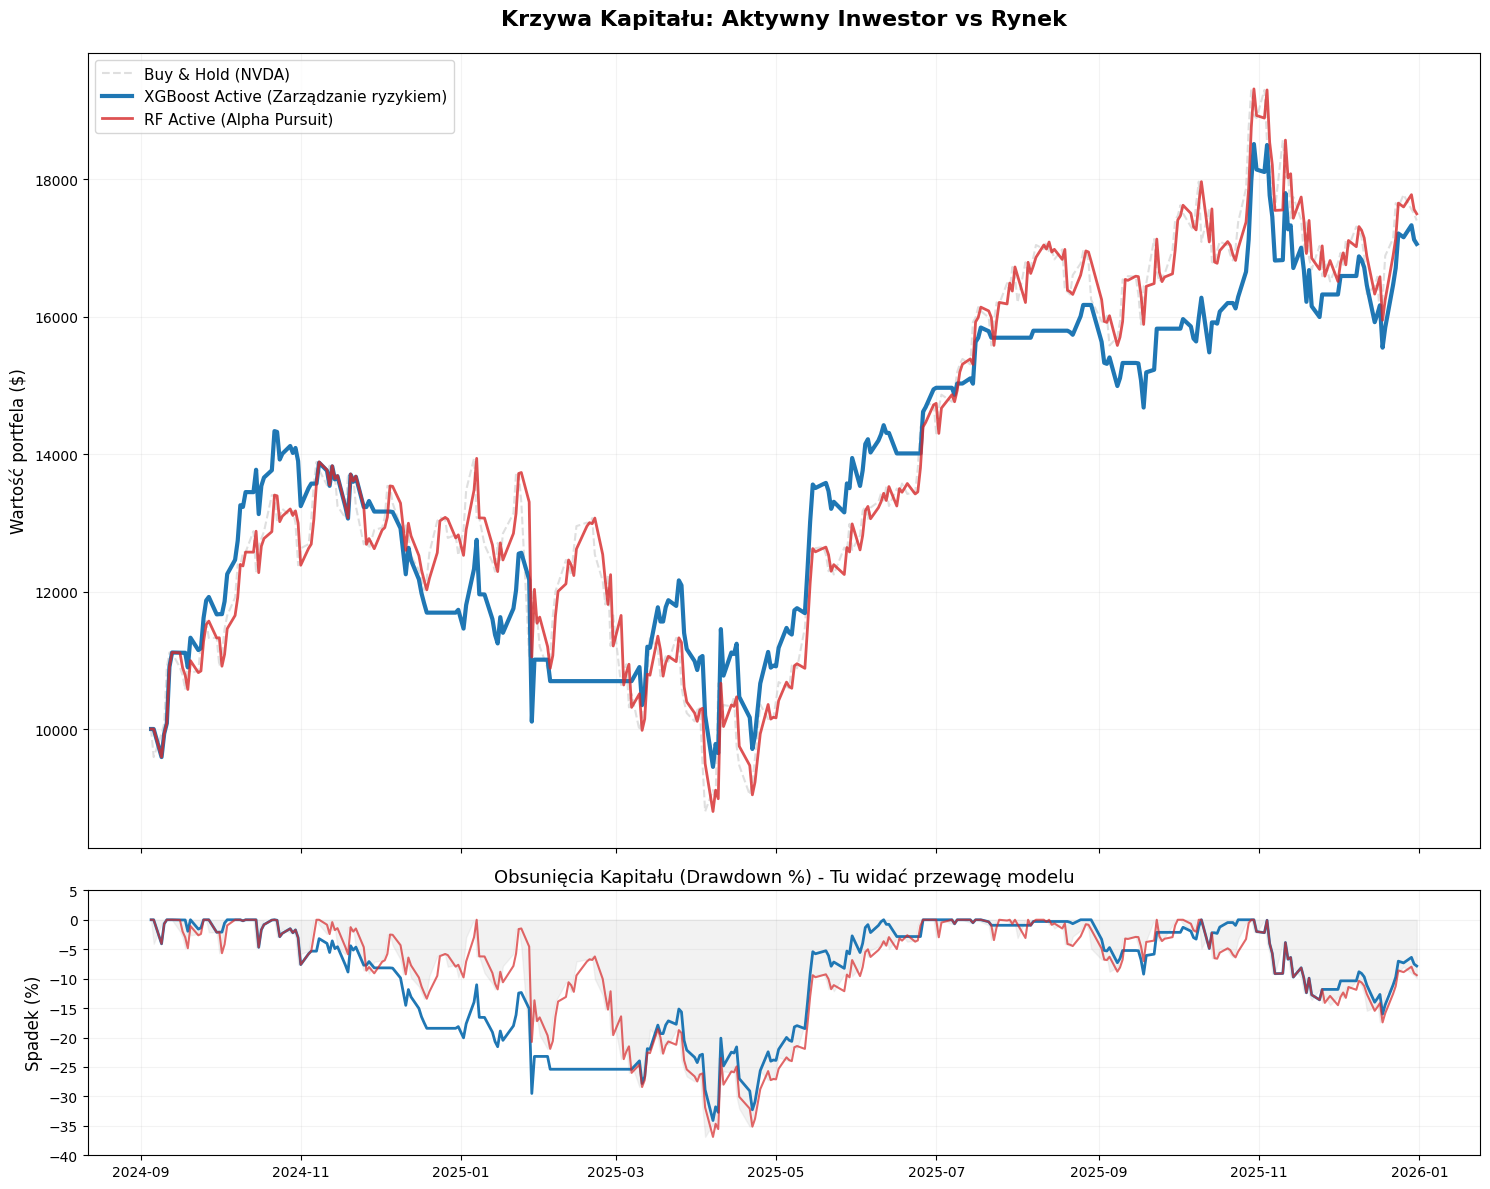

Końcowy wynik B&H: $17,403.21
Końcowy wynik XGB Active: $17,061.88 (Max DD: -34.10%)
Końcowy wynik RF Active: $17,500.26 (Max DD: -36.88%)


In [45]:
#  1. PRZYGOTOWANIE DANYCH 
equity_xgb = get_active_investor_backtest(xgb_v1.predict_proba(X_test_v1_np), daily_returns)
equity_rf = get_active_investor_backtest(rf_v1_final.predict_proba(X_test_v1_np), daily_returns)
equity_bnh = INITIAL_CAPITAL * (1 + daily_returns).cumprod()

# Funkcja pomocnicza do Drawdownu
def get_dd_series(equity_series):
    return (equity_series / equity_series.cummax() - 1) * 100

#  2. TWORZENIE PODWÓJNEGO WYKRESU 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# GŁÓWNY WYKRES KAPITAŁU
ax1.plot(equity_bnh, label='Buy & Hold (NVDA)', color='silver', alpha=0.5, lw=1.5, ls='--')
ax1.plot(equity_xgb, label='XGBoost Active (Zarządzanie ryzykiem)', color='#1f77b4', lw=3)
ax1.plot(equity_rf, label='RF Active (Alpha Pursuit)', color='#d62728', lw=2, alpha=0.8)

ax1.set_title('Krzywa Kapitału: Aktywny Inwestor vs Rynek', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Wartość portfela ($)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.15)

# WYKRES DRAWDOWNU (Tu widać różnice!)
ax2.fill_between(test_dates, get_dd_series(equity_bnh), 0, color='silver', alpha=0.2, label='B&H Drawdown')
ax2.plot(get_dd_series(equity_xgb), color='#1f77b4', lw=2, label='XGB Drawdown')
ax2.plot(get_dd_series(equity_rf), color='#d62728', lw=1.5, alpha=0.7)

ax2.set_title('Obsunięcia Kapitału (Drawdown %) - Tu widać przewagę modelu', fontsize=13)
ax2.set_ylabel('Spadek (%)', fontsize=12)
ax2.set_ylim(-40, 5) # Skala pod Twoje wyniki (-36%)
ax2.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

# Finalny Raport
print(f"Końcowy wynik B&H: ${equity_bnh.iloc[-1]:,.2f}")
print(f"Końcowy wynik XGB Active: ${equity_xgb.iloc[-1]:,.2f} (Max DD: {get_dd_series(equity_xgb).min():.2f}%)")
print(f"Końcowy wynik RF Active: ${equity_rf_active.iloc[-1]:,.2f} (Max DD: {get_dd_series(equity_rf).min():.2f}%)")

In [44]:
def get_max_drawdown(equity_series):
    rolling_max = equity_series.cummax()
    drawdown = (equity_series - rolling_max) / rolling_max
    return drawdown.min() * 100

print("\n" + "="*40)
print(f"{'STATYSTYKI RYZYKA':^40}")
print("="*40)
print(f"Max Drawdown B&H:    {get_max_drawdown(equity_bnh):.2f}%")
print(f"Max Drawdown XGB:    {get_max_drawdown(equity_xgb_active):.2f}%")
print(f"Max Drawdown RF:     {get_max_drawdown(equity_rf_active):.2f}%")
print("="*40)


           STATYSTYKI RYZYKA            
Max Drawdown B&H:    -36.88%
Max Drawdown XGB:    -34.10%
Max Drawdown RF:     -36.88%
